# NumerAI Rapid Research Template

In [1]:
import sys
import warnings
from pathlib import Path
import os

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")

try:
    NOTEBOOK_PATH = Path(__file__).resolve()
except NameError:
    NOTEBOOK_PATH = Path.cwd() / os.environ.get("JPY_SESSION_NAME", "notebook.ipynb")
    
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.data import (
    align_on_id,
    apply_validation_embargo,
    build_dataset_columns,
    load_benchmark_frame,
    load_feature_set,
    read_parquet_with_id_index,
)
from utils.metrics import calculate_metrics
from utils.model_benchmark import compare_top_models_with_current, record_model_metrics
from utils.postprocessing import build_evaluation_frame, neutralize_by_era, rank_by_era
from utils.visualization import display_metrics_table, plot_metric_over_time

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
print('>> Current Notebook Path:', NOTEBOOK_PATH)

>> Current Notebook Path: c:\dev\numer-AI\models\version_1\v1.5\notebook.ipynb


In [2]:
snnr_df = pd.read_csv("../../../exploratory_notebooks/outputs/snnr_weights_vs_correlation_v5.2.csv")
if "auxiliary_target" not in snnr_df.columns:
    raise KeyError("SNNR file must include 'auxiliary_target' column.")

if "snnr_weight" in snnr_df.columns:
    SNNR_WEIGHT_COL = "snnr_weight"
elif "snnr_weight_normalised" in snnr_df.columns:
    SNNR_WEIGHT_COL = "snnr_weight_normalised"
elif "weight" in snnr_df.columns:
    SNNR_WEIGHT_COL = "weight"
else:
    raise KeyError(
        "SNNR file must include one of: 'snnr_weight', 'snnr_weight_normalised', or 'weight'."
    )

snnr_df = snnr_df.sort_values(SNNR_WEIGHT_COL, ascending=False).reset_index(drop=True)
AUXILIARY_TARGETS = snnr_df["auxiliary_target"].astype(str).tolist()

print('>> Auxiliary target count:', len(AUXILIARY_TARGETS))
print('>> Top-5 SNNR targets:', AUXILIARY_TARGETS[:5])

>> Auxiliary target count: 17
>> Top-5 SNNR targets: ['target_jasper_20', 'target_teager2b_20', 'target_claudia_20', 'target_rowan_20', 'target_waldo_20']


In [3]:
DATA_VERSION = "v5.2"
DATA_DIR = "../../../data"
TRAIN_PATH = os.path.join(DATA_DIR, DATA_VERSION, "train.parquet")
VALIDATION_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet")
VALIDATION_BENCHMARKS_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")

FEATURE_SET_KEY = ["small"]
CUSTOM_FEATURE_LIST = None
MAIN_TARGET = "target_ender_20"
BENCHMARK_COL = "v52_lgbm_ender20"

# Data loading mode flags
USE_STANDARD_LOADER = True
ALIGN_VALIDATION_BENCHMARKS = True

# Target candidate controls
TARGET_TOP_K = 12
TARGET_MIN_COVERAGE = 0.50
TARGET_MIN_ABS_MAIN_CORR = 0.01
PRIORITY_TARGET_HINTS = ["target_victor_20", "target_xerxes_20", "target_teager_20"]

# Feature NaN handling strategy
FEATURE_NAN_STRATEGY = "neutral_0.5"  # {"neutral_0.5", "median"}

# Train/validation embargo (train -> validation)
EMBARGO_ERAS = 4

# Horizon-aware split controls (stronger gap if 60D specialists are active)
HORIZON_AWARE_EMBARGO = True
HORIZON_EXTRA_EMBARGO_60D = 2

# Triple split inside validation: V_eval and M_stack tail
META_TAIL_PCT = 0.10
META_EMBARGO_ERAS = 4

# Specialist bank hyperparameters
SPECIALIST_ALPHA_GRID = np.logspace(-2, 4, 13)
SPECIALIST_SHARPE_FLOOR = 0.50
MIN_SPECIALISTS_TO_KEEP = 6

# Meta model candidates
META_ALPHA_GRID = np.logspace(-2, 4, 9)
USE_NONLINEAR_META = True
LGBM_MAX_DEPTH = 3
LGBM_N_ESTIMATORS = 500
LGBM_LEARNING_RATE = 0.03
LGBM_COLSAMPLE = 0.8
LGBM_SUBSAMPLE = 0.8
LGBM_REG_L2 = 1.0
LGBM_VALID_TAIL_PCT = 0.20
LGBM_MIN_VALID_ERAS = 5
LGBM_EARLY_STOPPING_ROUNDS = 50
LGBM_VERBOSITY = -1
LGBM_FORCE_COL_WISE = True

# Postprocessing sweeps
NEUTRALIZATION_GRID = np.round(np.arange(0.0, 0.51, 0.1), 2).tolist()
BENCHMARK_DECORR_GRID = [0.00, 0.05, 0.10]

# Guardrails from baseline fa_v1.5.0_ridge_stacking_tail10
BASELINE_ANNUAL_RETURN_PCT = 9.5872
BASELINE_MMC_FLOOR = 0.0048656
BASELINE_MAX_DRAWDOWN = -0.11958
MMC_POSITIVE_ERA_FRACTION = 0.50

# Notebook run controls
MODEL_NAME = "fa_v1.5.1_return_max_hierarchy"
FORCE_HISTORY_OVERWRITE = True
RECORD_HISTORY = False
RETRAIN_ON_FULL_DATA = False

## 1) Load Data
Use the standard loader for the common case, or switch `USE_STANDARD_LOADER = False` to control paths and columns manually.

In [4]:
_, feature_set = load_feature_set(
    features_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"),
    feature_set_key=FEATURE_SET_KEY,
    feature_list=CUSTOM_FEATURE_LIST,
)

# Load all available auxiliary targets first; we prune later with quality filters.
all_aux_targets = [
    target_name
    for target_name in AUXILIARY_TARGETS
    if target_name != MAIN_TARGET
]
all_target_cols = [MAIN_TARGET] + all_aux_targets

train_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=all_target_cols,
)
validation_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=all_target_cols,
)

train_source = Path(TRAIN_PATH) if TRAIN_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "train.parquet"
validation_source = Path(VALIDATION_PATH) if VALIDATION_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "validation.parquet"
benchmark_source = (
    Path(VALIDATION_BENCHMARKS_PATH)
    if VALIDATION_BENCHMARKS_PATH is not None
    else Path(DATA_DIR) / DATA_VERSION / "validation_benchmark_models.parquet"
)

train = read_parquet_with_id_index(train_source, columns=train_columns)
validation = read_parquet_with_id_index(validation_source, columns=validation_columns)
validation = apply_validation_embargo(
    train=train,
    validation=validation,
    embargo_eras=EMBARGO_ERAS,
)

val_benchmarks = load_benchmark_frame(
    benchmark_path=benchmark_source,
    benchmark_columns=[BENCHMARK_COL],
)

if ALIGN_VALIDATION_BENCHMARKS:
    validation, val_benchmarks = align_on_id(validation, val_benchmarks)

if "era" not in train.columns or "era" not in validation.columns:
    raise KeyError("Both train and validation frames must include an 'era' column.")

train["era"] = train["era"].astype(int)
validation["era"] = validation["era"].astype(int)

if FEATURE_NAN_STRATEGY not in {"neutral_0.5", "median"}:
    raise ValueError("FEATURE_NAN_STRATEGY must be either 'neutral_0.5' or 'median'.")

if FEATURE_NAN_STRATEGY == "neutral_0.5":
    train.loc[:, feature_set] = train[feature_set].fillna(0.5)
    validation.loc[:, feature_set] = validation[feature_set].fillna(0.5)
else:
    train_feature_medians = train[feature_set].median()
    train.loc[:, feature_set] = train[feature_set].fillna(train_feature_medians)
    validation.loc[:, feature_set] = validation[feature_set].fillna(train_feature_medians)

# Main target is required for downstream evaluation.
train = train.dropna(subset=[MAIN_TARGET]).copy()
validation = validation.dropna(subset=[MAIN_TARGET]).copy()

# Re-align once more after any filtering.
validation, val_benchmarks = align_on_id(validation, val_benchmarks)

target_quality_records = []
for target_name in all_aux_targets:
    if target_name not in train.columns:
        continue

    coverage = float(train[target_name].notna().mean())
    aligned = train[[MAIN_TARGET, target_name]].dropna()
    corr_to_main = (
        float(aligned[target_name].corr(aligned[MAIN_TARGET]))
        if len(aligned) > 1
        else np.nan
    )

    snnr_match = snnr_df.loc[snnr_df["auxiliary_target"] == target_name]
    snnr_weight = (
        float(snnr_match[SNNR_WEIGHT_COL].iloc[0])
        if not snnr_match.empty
        else np.nan
    )

    target_quality_records.append(
        {
            "target_name": target_name,
            "coverage": coverage,
            "corr_to_main": corr_to_main,
            "abs_corr_to_main": abs(corr_to_main) if pd.notna(corr_to_main) else np.nan,
            "snnr_weight": snnr_weight,
        }
    )

target_quality_df = pd.DataFrame(target_quality_records)
if target_quality_df.empty:
    raise ValueError("No auxiliary targets available after initial loading.")

target_quality_df = target_quality_df.sort_values(
    by=["snnr_weight", "abs_corr_to_main"],
    ascending=[False, False],
).reset_index(drop=True)

quality_mask = (
    target_quality_df["coverage"] >= TARGET_MIN_COVERAGE
) & (
    target_quality_df["abs_corr_to_main"] >= TARGET_MIN_ABS_MAIN_CORR
)

selected_aux_targets = target_quality_df.loc[quality_mask, "target_name"].head(TARGET_TOP_K).tolist()

# Keep professor-priority targets if they exist and pass basic coverage checks.
for priority_target in PRIORITY_TARGET_HINTS:
    if priority_target in target_quality_df["target_name"].values and priority_target not in selected_aux_targets:
        priority_coverage = float(
            target_quality_df.loc[
                target_quality_df["target_name"] == priority_target,
                "coverage",
            ].iloc[0]
        )
        if priority_coverage >= TARGET_MIN_COVERAGE:
            selected_aux_targets.append(priority_target)

selected_aux_targets = [
    target_name for target_name in selected_aux_targets if target_name in train.columns
]

if len(selected_aux_targets) < MIN_SPECIALISTS_TO_KEEP:
    for target_name in target_quality_df["target_name"].tolist():
        if target_name not in selected_aux_targets:
            selected_aux_targets.append(target_name)
        if len(selected_aux_targets) >= MIN_SPECIALISTS_TO_KEEP:
            break

TARGETS_TO_TRAIN = selected_aux_targets
TARGET_COL = [MAIN_TARGET] + TARGETS_TO_TRAIN

print("Loader mode            :", "standard" if USE_STANDARD_LOADER else "custom")
print("Feature NaN strategy   :", FEATURE_NAN_STRATEGY)
print("Train shape            :", train.shape)
print("Validation shape       :", validation.shape)
print("Feature count          :", len(feature_set))
print("Candidate aux targets  :", len(all_aux_targets))
print("Selected aux targets   :", len(TARGETS_TO_TRAIN))
print("Benchmark col          :", BENCHMARK_COL)

print("\nSelected auxiliary targets:")
print(TARGETS_TO_TRAIN)

print("\nTarget quality preview:")
display(target_quality_df.head(20))

Loader mode            : standard
Feature NaN strategy   : neutral_0.5
Train shape            : (2746268, 61)
Validation shape       : (3886183, 61)
Feature count          : 42
Candidate aux targets  : 17
Selected aux targets   : 12
Benchmark col          : v52_lgbm_ender20

Selected auxiliary targets:
['target_jasper_20', 'target_teager2b_20', 'target_claudia_20', 'target_rowan_20', 'target_waldo_20', 'target_ender_60', 'target_xerxes_20', 'target_jeremy_20', 'target_cyrusd_20', 'target_agnes_20', 'target_victor_20', 'target_ralph_20']

Target quality preview:


,target_name,coverage,corr_to_main,abs_corr_to_main,snnr_weight
0,target_jasper_20,1.000000,0.794398,0.794398,0.300272
1,target_teager2b_20,1.000000,0.793034,0.793034,0.226785
2,target_claudia_20,1.000000,0.761413,0.761413,0.090945
3,target_rowan_20,1.000000,0.748382,0.748382,0.077177
4,target_waldo_20,1.000000,0.756072,0.756072,0.061258
5,target_ender_60,1.000000,0.465339,0.465339,0.041783
6,target_xerxes_20,1.000000,0.755318,0.755318,0.034451
7,target_jeremy_20,0.995122,0.734311,0.734311,0.034373
8,target_cyrusd_20,1.000000,0.756550,0.756550,0.026915
9,target_agnes_20,1.000000,0.675987,0.675987,0.020739


In [5]:
# Split TRAIN into specialist-train eras (90%) and meta-learner training tail (10%).
# Validation is reserved for evaluation only — it is never used in any training step here.
uses_60d_specialists = any(target_name.endswith("_60") for target_name in TARGETS_TO_TRAIN)
effective_meta_embargo = META_EMBARGO_ERAS + (
    HORIZON_EXTRA_EMBARGO_60D
    if HORIZON_AWARE_EMBARGO and uses_60d_specialists
    else 0
)

train_era_int = train["era"].astype(int)
sorted_train_eras = sorted(train_era_int.unique())
total_train_eras = len(sorted_train_eras)

meta_train_tail_count = max(1, int(round(total_train_eras * META_TAIL_PCT)))
required_eras = meta_train_tail_count + effective_meta_embargo + 1
if total_train_eras < required_eras:
    raise ValueError(
        "Not enough training eras for split policy. "
        f"Need at least {required_eras}, found {total_train_eras}."
    )

meta_train_tail_eras = sorted_train_eras[-meta_train_tail_count:]
if effective_meta_embargo > 0:
    meta_train_embargo_eras = sorted_train_eras[
        -(meta_train_tail_count + effective_meta_embargo) : -meta_train_tail_count
    ]
else:
    meta_train_embargo_eras = []
specialist_train_eras = sorted_train_eras[
    : total_train_eras - meta_train_tail_count - effective_meta_embargo
]

specialist_train_frame = train.loc[train_era_int.isin(specialist_train_eras)].copy()
meta_train_frame = train.loc[train_era_int.isin(meta_train_tail_eras)].copy()

if len(specialist_train_frame) == 0 or len(meta_train_frame) == 0:
    raise ValueError("Split produced an empty frame; adjust META_TAIL_PCT or META_EMBARGO_ERAS.")

if set(specialist_train_frame["era"].astype(int).unique()).intersection(
    set(meta_train_frame["era"].astype(int).unique())
):
    raise ValueError("Leakage guard failed: specialist and meta train eras overlap.")

print("Train era range             :", (train["era"].min(), train["era"].max()))
print("Specialist train eras       :", (specialist_train_frame["era"].min(), specialist_train_frame["era"].max()))
print("Meta-train tail eras        :", (meta_train_frame["era"].min(), meta_train_frame["era"].max()))
print("Meta embargo eras excluded  :", len(meta_train_embargo_eras))
print("Effective meta embargo      :", effective_meta_embargo)
print("Specialist train rows       :", specialist_train_frame.shape[0])
print("Meta-train rows             :", meta_train_frame.shape[0])
print("Validation rows (full eval) :", validation.shape[0])
print("60D-aware embargo active    :", uses_60d_specialists and HORIZON_AWARE_EMBARGO)


Train era range             : (np.int64(1), np.int64(574))
Specialist train eras       : (np.int64(1), np.int64(511))
Meta-train tail eras        : (np.int64(518), np.int64(574))
Meta embargo eras excluded  : 6
Effective meta embargo      : 6
Specialist train rows       : 2411533
Meta-train rows             : 305723
Validation rows (full eval) : 3886183
60D-aware embargo active    : True


## 2) Train Specialist Models
Train one Ridge per auxiliary target on `specialist_train_frame` (90% of train, minus embargo). Alpha is selected by out-of-sample Sharpe computed on `meta_train_frame` (the held-out 10%) — keeping validation completely untouched. Generate era-ranked predictions for both the meta-training tail and the full validation set.

In [6]:
import tqdm

if not TARGETS_TO_TRAIN:
    raise ValueError("No auxiliary targets available for specialist training after quality filtering.")


def _compute_era_sharpe(predictions: pd.Series, eras: pd.Series, target: pd.Series):
    eval_frame = pd.DataFrame(
        {
            "prediction": predictions,
            "era": eras,
            "target": target,
        }
    ).dropna()

    era_corrs = []
    for _, era_frame in eval_frame.groupby("era", sort=False):
        if era_frame["prediction"].nunique() < 2 or era_frame["target"].nunique() < 2:
            continue
        era_corrs.append(float(era_frame["prediction"].corr(era_frame["target"])))

    if not era_corrs:
        return -np.inf, np.array([], dtype=float)

    era_corrs_array = np.asarray(era_corrs, dtype=float)
    sharpe = float(era_corrs_array.mean() / (era_corrs_array.std(ddof=0) + 1.0e-12))
    return sharpe, era_corrs_array


print("Training specialist bank on targets:", len(TARGETS_TO_TRAIN))

trained_ridge_models = {}
validation_ranked_predictions = {}
meta_ranked_predictions = {}
specialist_stats = []

# Alpha selection Sharpe is computed on meta_train_frame (held-out 10% of train)
# to keep validation completely clean for final evaluation.
sharpe_eval_eras = meta_train_frame["era"]
sharpe_eval_target = meta_train_frame[MAIN_TARGET]

for target_name in tqdm.tqdm(
    TARGETS_TO_TRAIN,
    desc="Training specialist bank",
    unit="target",
):
    target_train_frame = specialist_train_frame.dropna(subset=[target_name]).copy()
    if target_train_frame.empty:
        continue

    X_train = target_train_frame[feature_set].to_numpy()
    y_train = target_train_frame[target_name].to_numpy()

    best_candidate = None
    for alpha in SPECIALIST_ALPHA_GRID:
        specialist_model = Ridge(alpha=float(alpha), random_state=42)
        specialist_model.fit(X_train, y_train)

        # Evaluate Sharpe on meta_train_frame (held-out 10% of train).
        sharpe_raw = pd.Series(
            specialist_model.predict(meta_train_frame[feature_set].to_numpy()),
            index=meta_train_frame.index,
            name=target_name,
        )
        sharpe_ranked = rank_by_era(
            predictions=sharpe_raw,
            eras=meta_train_frame["era"],
            index=meta_train_frame.index,
        )

        sharpe_score, era_corrs = _compute_era_sharpe(
            predictions=sharpe_ranked,
            eras=sharpe_eval_eras,
            target=sharpe_eval_target,
        )

        if best_candidate is None or sharpe_score > best_candidate["sharpe"]:
            best_candidate = {
                "model": specialist_model,
                "alpha": float(alpha),
                "sharpe": sharpe_score,
                "mean_era_corr": float(era_corrs.mean()) if era_corrs.size else np.nan,
                "std_era_corr": float(era_corrs.std(ddof=0)) if era_corrs.size else np.nan,
                "train_rows": int(len(target_train_frame)),
            }

    if best_candidate is None:
        continue

    trained_ridge_models[target_name] = best_candidate["model"]

    # Predictions on full validation (evaluation only — never used for training).
    val_raw = pd.Series(
        best_candidate["model"].predict(validation[feature_set].to_numpy()),
        index=validation.index,
        name=target_name,
    )
    validation_ranked_predictions[target_name] = rank_by_era(
        predictions=val_raw,
        eras=validation["era"],
        index=validation.index,
    )

    # Predictions on meta_train_frame for meta-learner training.
    meta_raw = pd.Series(
        best_candidate["model"].predict(meta_train_frame[feature_set].to_numpy()),
        index=meta_train_frame.index,
        name=target_name,
    )
    meta_ranked_predictions[target_name] = rank_by_era(
        predictions=meta_raw,
        eras=meta_train_frame["era"],
        index=meta_train_frame.index,
    )

    specialist_stats.append(
        {
            "target_name": target_name,
            "best_alpha": best_candidate["alpha"],
            "sharpe": best_candidate["sharpe"],
            "mean_era_corr": best_candidate["mean_era_corr"],
            "std_era_corr": best_candidate["std_era_corr"],
            "train_rows": best_candidate["train_rows"],
        }
    )

if not trained_ridge_models:
    raise ValueError("No specialist models were trained after alpha sweep.")

specialist_stats_df = pd.DataFrame(specialist_stats).sort_values(
    by=["sharpe", "mean_era_corr"],
    ascending=[False, False],
).reset_index(drop=True)

eligible_specialists = specialist_stats_df.loc[
    specialist_stats_df["sharpe"] >= SPECIALIST_SHARPE_FLOOR,
    "target_name",
].tolist()

if len(eligible_specialists) < MIN_SPECIALISTS_TO_KEEP:
    eligible_specialists = specialist_stats_df["target_name"].head(
        min(MIN_SPECIALISTS_TO_KEEP, len(specialist_stats_df))
    ).tolist()

if not eligible_specialists:
    raise ValueError("Specialist pruning removed all targets; relax SPECIALIST_SHARPE_FLOOR.")

TARGETS_TO_TRAIN = eligible_specialists
trained_ridge_models = {
    key: value for key, value in trained_ridge_models.items() if key in TARGETS_TO_TRAIN
}
validation_ranked_predictions = {
    key: value
    for key, value in validation_ranked_predictions.items()
    if key in TARGETS_TO_TRAIN
}
meta_ranked_predictions = {
    key: value for key, value in meta_ranked_predictions.items() if key in TARGETS_TO_TRAIN
}

specialist_stats_df = specialist_stats_df[
    specialist_stats_df["target_name"].isin(TARGETS_TO_TRAIN)
].reset_index(drop=True)

print("Specialists kept after pruning:", len(TARGETS_TO_TRAIN))
print("Sharpe floor:", SPECIALIST_SHARPE_FLOOR)
print("Selected specialists:", TARGETS_TO_TRAIN)
display(specialist_stats_df.head(20))


Training specialist bank on targets: 12


Training specialist bank: 100%|██████████| 12/12 [02:26<00:00, 12.19s/target]

Specialists kept after pruning: 12
Sharpe floor: 0.5
Selected specialists: ['target_cyrusd_20', 'target_xerxes_20', 'target_waldo_20', 'target_ralph_20', 'target_teager2b_20', 'target_jasper_20', 'target_agnes_20', 'target_ender_60', 'target_victor_20', 'target_rowan_20', 'target_jeremy_20', 'target_claudia_20']


,target_name,best_alpha,sharpe,mean_era_corr,std_era_corr,train_rows
0,target_cyrusd_20,1000.000000,1.731428,0.021052,0.012159,2411533
1,target_xerxes_20,10000.000000,1.681202,0.020699,0.012312,2411533
2,target_waldo_20,100.000000,1.500757,0.018360,0.012234,2411533
3,target_ralph_20,31.622777,1.482965,0.018710,0.012617,2411533
4,target_teager2b_20,3162.277660,1.469162,0.018417,0.012536,2411533
5,target_jasper_20,3162.277660,1.442096,0.019426,0.013471,2411533
6,target_agnes_20,10000.000000,1.433813,0.014677,0.010237,2411533
7,target_ender_60,3162.277660,1.427746,0.018502,0.012959,2411533
8,target_victor_20,316.227766,1.355197,0.018294,0.013499,2411533
9,target_rowan_20,3162.277660,1.335523,0.017327,0.012974,2411533


In [7]:
# Assemble specialist rank-prediction matrices for stacking
validation_meta_features = pd.DataFrame(validation_ranked_predictions).sort_index()
meta_training_features = pd.DataFrame(meta_ranked_predictions).sort_index()

if validation_meta_features.empty or meta_training_features.empty:
    raise ValueError("Specialist prediction matrices are empty.")

print("Validation meta-feature shape:", validation_meta_features.shape)
print("Meta-training feature shape   :", meta_training_features.shape)
display(validation_meta_features.head())

Validation meta-feature shape: (3886183, 12)
Meta-training feature shape   : (305723, 12)


,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20
id,,,,,,,,,,,,
n000001c6d04d3ef,0.614180,0.605441,0.613026,0.588293,0.625556,0.565540,0.583512,0.578730,0.553833,0.742292,0.552020,0.631987
n0000065fb5955c5,0.289141,0.291035,0.279040,0.317551,0.156250,0.321338,0.147254,0.330966,0.147885,0.195391,0.156723,0.144097
n00000acaae936c8,0.193656,0.209733,0.199594,0.213499,0.323581,0.224652,0.199305,0.698870,0.198436,0.266367,0.208720,0.278969
n00001041c3474c5,0.711201,0.714350,0.714650,0.741191,0.807467,0.760834,0.782126,0.817364,0.802219,0.612536,0.771180,0.789024
n0000123b62b6d6d,0.738378,0.752226,0.674250,0.663370,0.854105,0.645236,0.802835,0.755687,0.818332,0.688427,0.790307,0.859545


In [8]:
# Keep only specialist predictions as meta inputs (no mean/rank-average baseline).
validation_predictions_df = validation_meta_features.copy()
validation_predictions_df.head()

,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20
id,,,,,,,,,,,,
n000001c6d04d3ef,0.614180,0.605441,0.613026,0.588293,0.625556,0.565540,0.583512,0.578730,0.553833,0.742292,0.552020,0.631987
n0000065fb5955c5,0.289141,0.291035,0.279040,0.317551,0.156250,0.321338,0.147254,0.330966,0.147885,0.195391,0.156723,0.144097
n00000acaae936c8,0.193656,0.209733,0.199594,0.213499,0.323581,0.224652,0.199305,0.698870,0.198436,0.266367,0.208720,0.278969
n00001041c3474c5,0.711201,0.714350,0.714650,0.741191,0.807467,0.760834,0.782126,0.817364,0.802219,0.612536,0.771180,0.789024
n0000123b62b6d6d,0.738378,0.752226,0.674250,0.663370,0.854105,0.645236,0.802835,0.755687,0.818332,0.688427,0.790307,0.859545


In [9]:
print(
    "Meta-feature matrix range (global min/max):",
    float(validation_meta_features.min().min()),
    float(validation_meta_features.max().max()),
)
display(validation_meta_features.head())

Meta-feature matrix range (global min/max): 0.00013681762210972773 1.0


,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20
id,,,,,,,,,,,,
n000001c6d04d3ef,0.614180,0.605441,0.613026,0.588293,0.625556,0.565540,0.583512,0.578730,0.553833,0.742292,0.552020,0.631987
n0000065fb5955c5,0.289141,0.291035,0.279040,0.317551,0.156250,0.321338,0.147254,0.330966,0.147885,0.195391,0.156723,0.144097
n00000acaae936c8,0.193656,0.209733,0.199594,0.213499,0.323581,0.224652,0.199305,0.698870,0.198436,0.266367,0.208720,0.278969
n00001041c3474c5,0.711201,0.714350,0.714650,0.741191,0.807467,0.760834,0.782126,0.817364,0.802219,0.612536,0.771180,0.789024
n0000123b62b6d6d,0.738378,0.752226,0.674250,0.663370,0.854105,0.645236,0.802835,0.755687,0.818332,0.688427,0.790307,0.859545


## 3) Train Meta-Learner
Train meta-learner candidates (Ridge alpha sweep + optional LGBM) on the `meta_train_frame` (10% tail of train). Sweep neutralization and benchmark decorrelation; evaluate all candidates on the **full** validation set. Select the best candidate by guardrail-filtered annualized return.

In [10]:
print("Neutralization grid:", NEUTRALIZATION_GRID)
print("Benchmark decorr grid:", BENCHMARK_DECORR_GRID)

# Meta-learner trains on the 10% train tail (meta_train_frame).
# Benchmark data does not exist for train rows, so meta features are specialist predictions only.
meta_target = meta_train_frame[MAIN_TARGET].dropna()
common_meta_index = meta_training_features.index.intersection(meta_target.index)

if len(common_meta_index) == 0:
    raise ValueError("No aligned rows for meta-learner training after dropping NaN main target.")

meta_X = meta_training_features.loc[common_meta_index].copy()
meta_y = meta_target.loc[common_meta_index].copy()
meta_eras = meta_train_frame.loc[common_meta_index, "era"].copy()

# Candidate evaluation uses the full validation set.
meta_eval_index = validation_meta_features.index
eval_X = validation_meta_features.loc[meta_eval_index].copy()
eval_eras = validation.loc[meta_eval_index, "era"].copy()
eval_features = validation.loc[meta_eval_index, feature_set].copy()
eval_benchmark = val_benchmarks.loc[meta_eval_index, BENCHMARK_COL].copy()

eval_benchmark_ranked = rank_by_era(
    predictions=eval_benchmark,
    eras=eval_eras,
    index=meta_eval_index,
)

# LGBM internal early-stopping split: temporal tail of meta_train_frame.
meta_era_int = meta_eras.astype(int)
meta_unique_eras = sorted(meta_era_int.unique())
if len(meta_unique_eras) <= 1:
    lgbm_train_mask = pd.Series(True, index=meta_X.index)
    lgbm_valid_mask = pd.Series(False, index=meta_X.index)
else:
    requested_valid_eras = max(
        LGBM_MIN_VALID_ERAS,
        int(round(len(meta_unique_eras) * LGBM_VALID_TAIL_PCT)),
    )
    valid_era_count = min(requested_valid_eras, max(1, len(meta_unique_eras) - 1))
    lgbm_valid_eras = set(meta_unique_eras[-valid_era_count:])
    lgbm_valid_mask = meta_era_int.isin(lgbm_valid_eras)
    lgbm_train_mask = ~lgbm_valid_mask

lgbm_X_train = meta_X.loc[lgbm_train_mask].copy()
lgbm_y_train = meta_y.loc[lgbm_train_mask].copy()
lgbm_X_valid = meta_X.loc[lgbm_valid_mask].copy()
lgbm_y_valid = meta_y.loc[lgbm_valid_mask].copy()

if lgbm_X_train.empty:
    lgbm_X_train = meta_X.copy()
    lgbm_y_train = meta_y.copy()

if lgbm_X_valid.empty:
    lgbm_X_valid = None
    lgbm_y_valid = None
    lgbm_valid_era_n = 0
else:
    lgbm_valid_era_n = int(meta_eras.loc[lgbm_X_valid.index].nunique())

print("Meta-train rows:", len(meta_X))
print("Meta-train eras:", meta_eras.nunique())
print("Meta feature count:", meta_X.shape[1])
print("LGBM train rows:", len(lgbm_X_train))
print("LGBM valid rows:", 0 if lgbm_X_valid is None else len(lgbm_X_valid))
print("LGBM valid eras:", lgbm_valid_era_n)


def _fit_nonnegative_ridge(X: np.ndarray, y: np.ndarray, alpha: float):
    try:
        model = Ridge(alpha=float(alpha), positive=True, random_state=42)
        model.fit(X, y)
        return {"kind": "native", "model": model}
    except TypeError:
        fallback = Ridge(alpha=float(alpha), random_state=42)
        fallback.fit(X, y)
        clipped_coef = np.clip(fallback.coef_, a_min=0.0, a_max=None)
        if clipped_coef.sum() <= 0:
            clipped_coef = np.ones_like(clipped_coef, dtype=float)
        clipped_coef = clipped_coef / (clipped_coef.sum() + 1.0e-12)
        return {
            "kind": "fallback",
            "intercept": float(fallback.intercept_),
            "coef": clipped_coef,
        }


def _predict_nonnegative_ridge(bundle, X: np.ndarray) -> np.ndarray:
    if bundle["kind"] == "native":
        return bundle["model"].predict(X)
    return X @ bundle["coef"] + bundle["intercept"]


model_candidates = []

for alpha in META_ALPHA_GRID:
    ridge_bundle = _fit_nonnegative_ridge(
        X=meta_X.to_numpy(),
        y=meta_y.to_numpy(),
        alpha=float(alpha),
    )
    ridge_raw = pd.Series(
        _predict_nonnegative_ridge(ridge_bundle, eval_X.to_numpy()),
        index=meta_eval_index,
        name="prediction",
    )
    model_candidates.append(
        {
            "model_family": "ridge_nonneg",
            "model_spec": f"alpha={float(alpha):.4g}",
            "raw_predictions": ridge_raw,
        }
    )

if USE_NONLINEAR_META:
    lgbm_model = LGBMRegressor(
        objective="regression",
        n_estimators=LGBM_N_ESTIMATORS,
        learning_rate=LGBM_LEARNING_RATE,
        max_depth=LGBM_MAX_DEPTH,
        subsample=LGBM_SUBSAMPLE,
        colsample_bytree=LGBM_COLSAMPLE,
        reg_lambda=LGBM_REG_L2,
        verbosity=LGBM_VERBOSITY,
        force_col_wise=LGBM_FORCE_COL_WISE,
        random_state=42,
        n_jobs=-1,
    )

    lgbm_fit_kwargs = {}
    if lgbm_X_valid is not None and lgbm_y_valid is not None:
        lgbm_fit_kwargs["eval_set"] = [(lgbm_X_valid, lgbm_y_valid)]
        lgbm_fit_kwargs["eval_metric"] = "l2"
        lgbm_fit_kwargs["callbacks"] = [
            early_stopping(
                stopping_rounds=LGBM_EARLY_STOPPING_ROUNDS,
                verbose=False,
            )
        ]

    lgbm_model.fit(lgbm_X_train, lgbm_y_train, **lgbm_fit_kwargs)
    lgbm_best_iteration = getattr(lgbm_model, "best_iteration_", None)
    lgbm_predict_kwargs = {}
    if lgbm_best_iteration is not None and lgbm_best_iteration > 0:
        lgbm_predict_kwargs["num_iteration"] = int(lgbm_best_iteration)

    lgbm_raw = pd.Series(
        lgbm_model.predict(eval_X, **lgbm_predict_kwargs),
        index=meta_eval_index,
        name="prediction",
    )
    best_iter_text = str(lgbm_best_iteration) if lgbm_best_iteration is not None else "none"
    model_candidates.append(
        {
            "model_family": "lgbm",
            "model_spec": (
                f"depth={LGBM_MAX_DEPTH},n_estimators={LGBM_N_ESTIMATORS},"
                f"lr={LGBM_LEARNING_RATE},es={LGBM_EARLY_STOPPING_ROUNDS},"
                f"best_iter={best_iter_text}"
            ),
            "raw_predictions": lgbm_raw,
        }
    )

if not model_candidates:
    raise ValueError("No meta-model candidates were generated.")

candidate_records = []
candidate_artifacts = {}

for model_candidate in model_candidates:
    base_raw = model_candidate["raw_predictions"]

    for decorr_strength in BENCHMARK_DECORR_GRID:
        decorrelated_raw = pd.Series(
            base_raw - (decorr_strength * eval_benchmark_ranked),
            index=meta_eval_index,
            name="prediction",
        )

        for neutralization_prop in NEUTRALIZATION_GRID:
            if neutralization_prop > 0:
                candidate_predictions = neutralize_by_era(
                    predictions=decorrelated_raw,
                    eras=eval_eras,
                    features=eval_features,
                    proportion=float(neutralization_prop),
                    rank_output=True,
                )
            else:
                candidate_predictions = rank_by_era(
                    predictions=decorrelated_raw,
                    eras=eval_eras,
                    index=meta_eval_index,
                )

            candidate_eval_frame = build_evaluation_frame(
                validation=validation.loc[meta_eval_index],
                predictions=candidate_predictions,
                target_col=MAIN_TARGET,
            )

            candidate_metrics, candidate_per_era = calculate_metrics(
                df_validation=candidate_eval_frame,
                benchmarks=val_benchmarks,
                features=feature_set,
                target_col=MAIN_TARGET,
                benchmark_col=BENCHMARK_COL,
                fast_metrics=True,
            )

            positive_mmc_ratio = float((candidate_per_era["BMC20"] > 0).mean())
            passes_guardrails = (
                candidate_metrics["9_Annualized_Return_PCT"] > BASELINE_ANNUAL_RETURN_PCT
                and candidate_metrics["4_Mean_BMC20"] >= BASELINE_MMC_FLOOR
                and candidate_metrics["7_Max_Drawdown_CORR"] >= BASELINE_MAX_DRAWDOWN
                and positive_mmc_ratio >= MMC_POSITIVE_ERA_FRACTION
            )

            run_key = (
                f"{model_candidate['model_family']}|{model_candidate['model_spec']}|"
                f"decorr={float(decorr_strength):.2f}|neu={float(neutralization_prop):.2f}"
            )

            candidate_records.append(
                {
                    "run_key": run_key,
                    "model_family": model_candidate["model_family"],
                    "model_spec": model_candidate["model_spec"],
                    "decorr_strength": float(decorr_strength),
                    "neutralization": float(neutralization_prop),
                    "9_Annualized_Return_PCT": float(candidate_metrics["9_Annualized_Return_PCT"]),
                    "1_RAPS": float(candidate_metrics["1_RAPS"]),
                    "4_Mean_BMC20": float(candidate_metrics["4_Mean_BMC20"]),
                    "3_Mean_CORR20V2": float(candidate_metrics["3_Mean_CORR20V2"]),
                    "7_Max_Drawdown_CORR": float(candidate_metrics["7_Max_Drawdown_CORR"]),
                    "10_Benchmark_Corr": float(candidate_metrics["10_Benchmark_Corr"]),
                    "positive_mmc_ratio": positive_mmc_ratio,
                    "passes_guardrails": bool(passes_guardrails),
                }
            )

            candidate_artifacts[run_key] = {
                "predictions": candidate_predictions,
                "metrics": candidate_metrics,
                "per_era": candidate_per_era,
            }

candidate_results_df = pd.DataFrame(candidate_records)
if candidate_results_df.empty:
    raise ValueError("No candidate runs were evaluated.")

candidate_results_df = candidate_results_df.sort_values(
    by=["passes_guardrails", "9_Annualized_Return_PCT", "1_RAPS"],
    ascending=[False, False, False],
).reset_index(drop=True)

passing_candidates = candidate_results_df[candidate_results_df["passes_guardrails"]].copy()
if passing_candidates.empty:
    selected_candidate_row = candidate_results_df.iloc[0]
    print(">> WARNING: No candidate passed all guardrails. Selecting best overall for analysis.")
else:
    selected_candidate_row = passing_candidates.iloc[0]
    print(">> Selected candidate passed all guardrails.")

selected_run_key = selected_candidate_row["run_key"]
selected_artifact = candidate_artifacts[selected_run_key]

final_validation_predictions = selected_artifact["predictions"]
validation_model_frame = validation.loc[final_validation_predictions.index].copy()

selected_metrics_preview = selected_artifact["metrics"]
MODEL_NAME = (
    f"fa_v1.5.1_{selected_candidate_row['model_family']}"
    f"_decorr{selected_candidate_row['decorr_strength']:.2f}"
    f"_neu{selected_candidate_row['neutralization']:.2f}"
)

print("Selected run key          :", selected_run_key)
print("Selected annualized return:", round(selected_metrics_preview["9_Annualized_Return_PCT"], 4))
print("Selected mean BMC/MMC     :", round(selected_metrics_preview["4_Mean_BMC20"], 6))
print("Selected max drawdown     :", round(selected_metrics_preview["7_Max_Drawdown_CORR"], 6))
print("Updated model name        :", MODEL_NAME)

display(candidate_results_df.head(20))


Neutralization grid: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
Benchmark decorr grid: [0.0, 0.05, 0.1]
Meta-train rows: 305723
Meta-train eras: 57
Meta feature count: 12
LGBM train rows: 244024
LGBM valid rows: 61699
LGBM valid eras: 11
>> WARNING: No candidate passed all guardrails. Selecting best overall for analysis.
Selected run key          : lgbm|depth=3,n_estimators=500,lr=0.03,es=50,best_iter=85|decorr=0.00|neu=0.00
Selected annualized return: 3.3448
Selected mean BMC/MMC     : -6.5e-05
Selected max drawdown     : -0.126952
Updated model name        : fa_v1.5.1_lgbm_decorr0.00_neu0.00


,run_key,model_family,model_spec,decorr_strength,neutralization,9_Annualized_Return_PCT,1_RAPS,4_Mean_BMC20,3_Mean_CORR20V2,7_Max_Drawdown_CORR,10_Benchmark_Corr,positive_mmc_ratio,passes_guardrails
0,"lgbm|depth=3,n_estimators=500,lr=0.03,es=50,be...",lgbm,"depth=3,n_estimators=500,lr=0.03,es=50,best_it...",0.0,0.0,3.344801,-0.125928,-0.000065,0.008711,-0.126952,0.264990,0.5008,False
1,ridge_nonneg|alpha=0.01|decorr=0.00|neu=0.20,ridge_nonneg,alpha=0.01,0.0,0.2,3.274482,-0.142576,-0.000594,0.010125,-0.124699,0.333368,0.4608,False
2,ridge_nonneg|alpha=0.05623|decorr=0.00|neu=0.20,ridge_nonneg,alpha=0.05623,0.0,0.2,3.274482,-0.142576,-0.000594,0.010125,-0.124699,0.333368,0.4608,False
3,ridge_nonneg|alpha=0.3162|decorr=0.00|neu=0.20,ridge_nonneg,alpha=0.3162,0.0,0.2,3.274482,-0.142576,-0.000594,0.010125,-0.124699,0.333368,0.4608,False
4,ridge_nonneg|alpha=1.778|decorr=0.00|neu=0.20,ridge_nonneg,alpha=1.778,0.0,0.2,3.274482,-0.142576,-0.000594,0.010125,-0.124699,0.333368,0.4608,False
5,ridge_nonneg|alpha=10|decorr=0.00|neu=0.20,ridge_nonneg,alpha=10,0.0,0.2,3.274482,-0.142576,-0.000594,0.010125,-0.124699,0.333368,0.4608,False
6,ridge_nonneg|alpha=56.23|decorr=0.00|neu=0.20,ridge_nonneg,alpha=56.23,0.0,0.2,3.274482,-0.142576,-0.000594,0.010125,-0.124699,0.333368,0.4608,False
7,ridge_nonneg|alpha=0.01|decorr=0.00|neu=0.30,ridge_nonneg,alpha=0.01,0.0,0.3,3.249794,-0.118455,-0.000553,0.009942,-0.122631,0.331583,0.4800,False
8,ridge_nonneg|alpha=0.05623|decorr=0.00|neu=0.30,ridge_nonneg,alpha=0.05623,0.0,0.3,3.249794,-0.118455,-0.000553,0.009942,-0.122631,0.331583,0.4800,False
9,ridge_nonneg|alpha=0.3162|decorr=0.00|neu=0.30,ridge_nonneg,alpha=0.3162,0.0,0.3,3.249794,-0.118455,-0.000553,0.009942,-0.122631,0.331583,0.4800,False


## 4) Evaluate Meta-Learner


Meta-learner metrics:
                             KEY PERFORMANCE METRICS vs GOALS                             


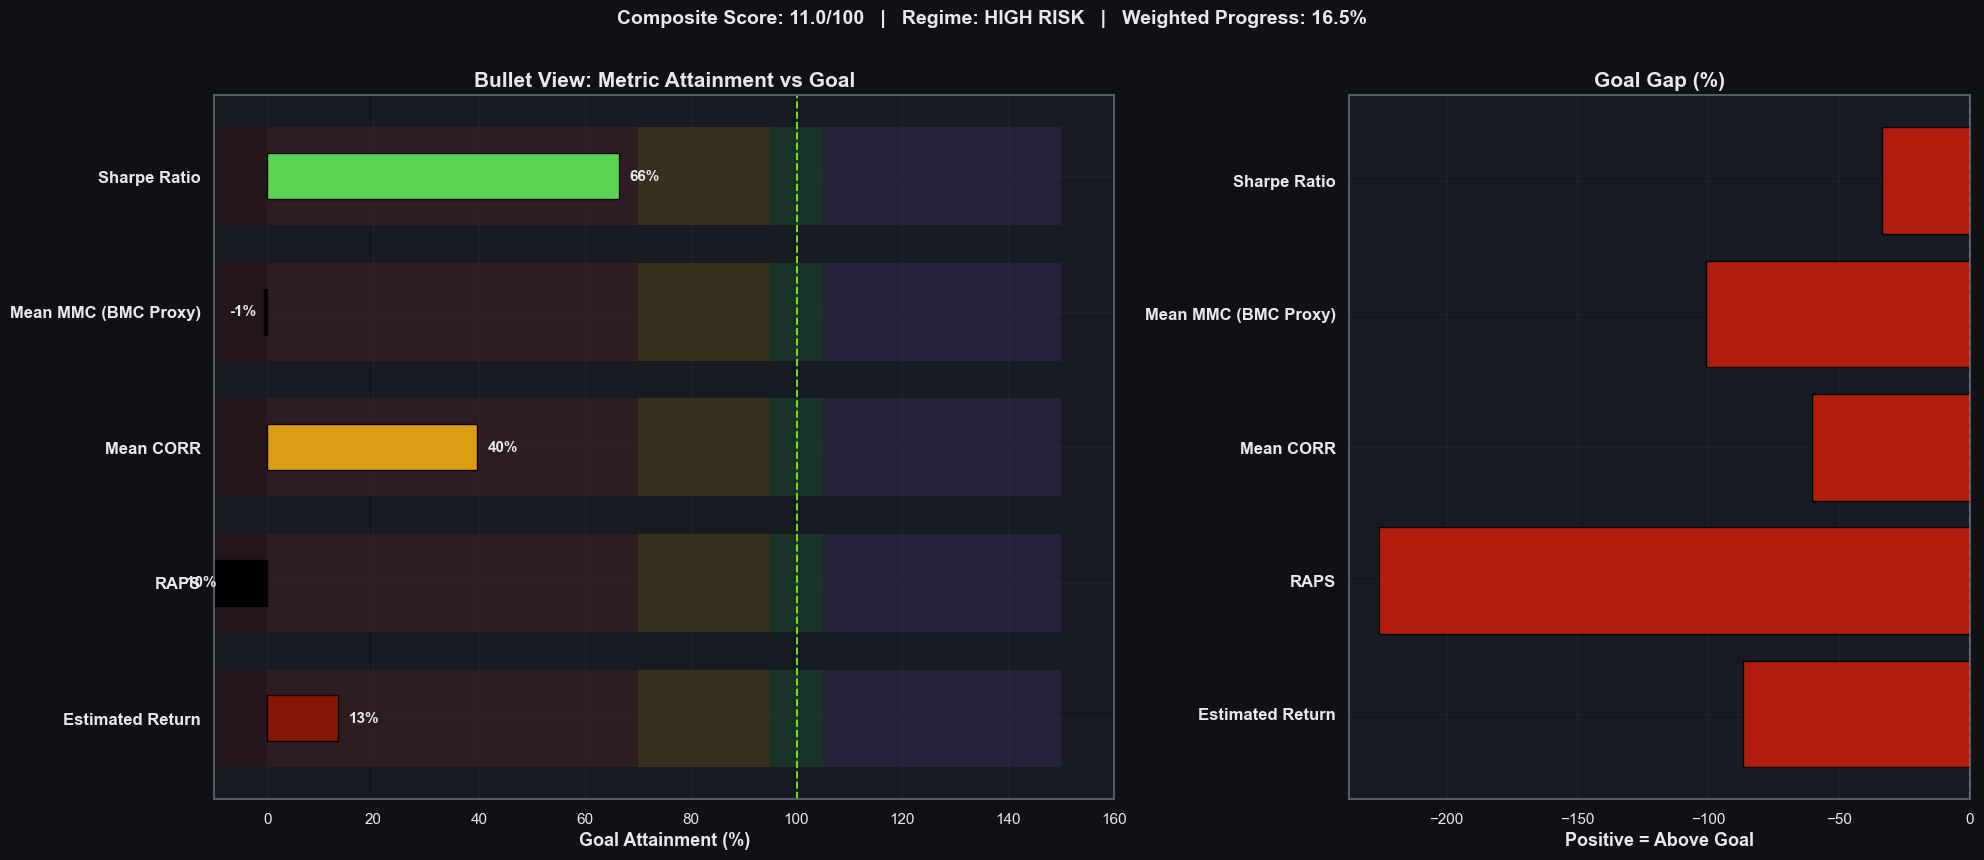

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,+3.34%,+25.00%,-86.6%,13.4%,🔴 BELOW,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,RAPS,-0.1259,+0.1000,-225.9%,-10.0%,🔴 BELOW,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),-0.00007,+0.01000,-100.7%,-0.7%,🔴 BELOW,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,Mean CORR,+0.00871,+0.02200,-60.4%,39.6%,🔴 BELOW,Official Numerai correlation score; strong models are often 0.01-0.03
Quality,Win Rate,74.6%,85.0%,-12.3%,87.7%,🟡 CLOSE,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Payout Sharpe,+0.1882,+1.2500,-84.9%,15.1%,🔴 BELOW,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,Sharpe Ratio,+0.6649,+1.0000,-33.5%,66.5%,🟠 LAGGING,Risk-adjusted return consistency
Risk,Max Drawdown,-0.12695,-0.10000,-27.0%,73.0%,🟠 LAGGING,Worst sustained CORR cumulative loss
Risk,MMC Volatility,+0.01110,—,—,—,—,Standard deviation of era-by-era MMC


In [11]:
evaluation_frame = build_evaluation_frame(
    validation=validation_model_frame,
    predictions= final_validation_predictions,
    target_col=MAIN_TARGET,
)

metrics, per_era_df = calculate_metrics(
    df_validation=evaluation_frame,
    benchmarks=val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
 )

print("\nMeta-learner metrics:")
display_metrics_table(metrics, extended=True)

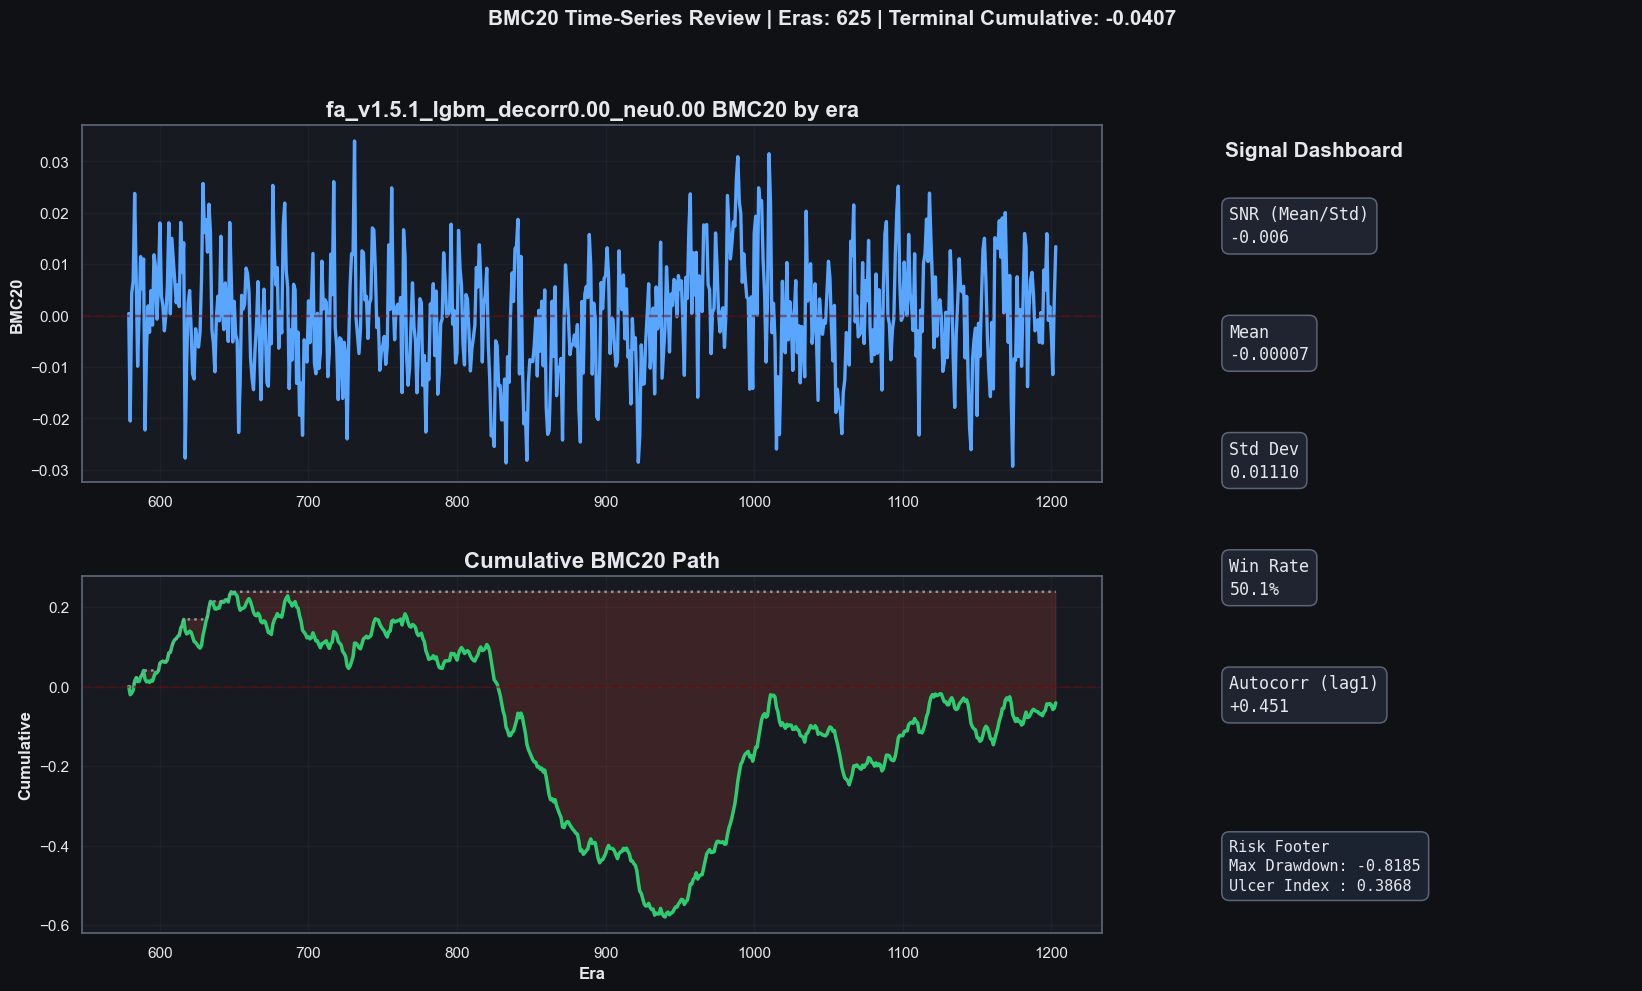

In [12]:
plot_metric_over_time(
    per_era_df=per_era_df,
    metric="BMC20",
    title=f"{MODEL_NAME} BMC20 by era",
)


In [13]:
assert False

AssertionError: 

In [14]:
history_df, record = record_model_metrics(
    metrics=metrics,
    model_name=MODEL_NAME,
    notebook_name=NOTEBOOK_PATH.name,
    force=FORCE_HISTORY_OVERWRITE,
)
display(pd.DataFrame([record]))


,run_id,model_name,9_Annualized_Return_PCT,4_Mean_BMC20,3_Mean_CORR20V2,1_RAPS,5_Sharpe_CORR,2_Sharpe_Payout,7_Max_Drawdown_CORR,8_Win_Rate,6_Mean_FNC,10_Benchmark_Corr,11_BMC_Volatility,4_Mean_MMC20,11_MMC_Volatility,notebook_name,timestamp_utc,history_path,status,message
6,f530fe22,fa_v1.5.1_lgbm_decorr0.00_neu0.00,3.3448,-0.000065,0.008711,-0.12593,0.66489,0.18816,-0.12695,0.7456,NaN,0.26499,0.011104,-0.000065,0.011104,notebook.ipynb,2026-04-07 18:56:18,C:\dev\numer-AI\submissions\model_metrics_hist...,skipped,Model exists but metrics are unchanged. Nothin...


In [15]:
if record.get("run_id") is None:
    print("Leaderboard comparison skipped because no run was recorded.")
else:
    leaderboard, is_top_model = compare_top_models_with_current(
        current_run_id=record["run_id"],
        top_n=5,
    )

rank,run id,model name,Annualized Return PCT,Mean BMC20,Mean CORR20V2,RAPS,Sharpe CORR,Sharpe Payout,Max Drawdown CORR,Win Rate,Mean FNC,Benchmark Corr,BMC Volatility,MMC Volatility,timestamp utc
#1,fbb644a7,Shallow LGBM BaselineTOP 1,+5.1137%,-0.00017024,+0.013375,+0.15662,+0.96102,+0.29741,-0.081574,+0.8224,-,+0.39982,+0.010492,+0.010492,2026-04-06 19:03:43
#2,8335c597,fa_v1.5.0_ridge_stacking_tail10TOP 2,+3.9758%,+0.00069765,+0.0079816,+0.0021969,+0.62804,+0.22707,-0.17236,+0.7584,-,+0.25089,+0.010871,+0.010871,2026-04-06 19:43:31
#3,7d85f24f,ridge_baseline_templateTOP 3,+3.6996%,-0.00038894,+0.010567,-0.26594,+0.7651,+0.2014,-0.158,+0.7744,-,+0.32543,+0.011406,+0.011406,2026-03-29 18:15:25
#4,f530fe22,fa_v1.5.1_lgbm_decorr0.00_neu0.00CURRENT RUN,+3.3448%,-6.5168e-05,+0.008711,-0.12593,+0.66489,+0.18816,-0.12695,+0.7456,-,+0.26499,+0.011104,+0.011104,2026-04-07 18:56:18
#5,096fface,previous_era_target_mean,-0.25314%,-8.3872e-05,-0.00032203,-0.19054,-0.026164,-0.012723,-0.36695,+0.47218,-,+7.5847e-05,+0.011045,+0.011045,2026-03-29 18:20:57


## 5) Full-Data Retrain Setup
Specialists are trained on the **90% specialist train eras** (same split as research phase) **plus ALL of validation**.  
The meta-learner is trained on the **same 10% tail from train** (`meta_train_frame`) used in the research phase — keeping the meta-training data identical and leak-free.  
Validation is never used to train the meta-learner.

In [16]:
# Full-data retrain setup.
# Specialists: trained on 90% of train (specialist_train_eras) + ALL of validation.
# Meta-learner: trained on the same 10% tail from train (meta_train_frame) as in research phase.
# This mirrors the research-phase stacking split exactly — no new meta split is needed.
# Validation is safely included in specialist training because it is temporally after
# the meta tail, so no specialist-to-meta leakage is introduced.

full_validation = read_parquet_with_id_index(validation_source, columns=validation_columns)
full_validation["era"] = full_validation["era"].astype(int)

if FEATURE_NAN_STRATEGY == "neutral_0.5":
    full_validation.loc[:, feature_set] = full_validation[feature_set].fillna(0.5)
else:
    full_feature_medians = train[feature_set].median()
    full_validation.loc[:, feature_set] = full_validation[feature_set].fillna(full_feature_medians)

full_validation = full_validation.dropna(subset=[MAIN_TARGET])

# Meta training data: reuse the 10% train tail from the research phase directly.
full_meta_train_frame = meta_train_frame.copy()

# Specialist training data: 90% of train (excluding meta tail + embargo) + ALL of validation.
full_specialist_train_frame = pd.concat(
    [specialist_train_frame, full_validation], axis=0
)
full_specialist_train_frame = (
    full_specialist_train_frame[~full_specialist_train_frame.index.duplicated(keep="last")]
    .sort_index()
)

# Full dataset for scoring at export time (all train + all validation rows).
full_dataset = pd.concat([train, full_validation], axis=0)
full_dataset = full_dataset[~full_dataset.index.duplicated(keep="last")].sort_index()

if full_specialist_train_frame.empty or full_meta_train_frame.empty:
    raise ValueError("Full-data split produced empty specialist or meta frame.")

print(f"Meta policy                 : reusing 10% train tail from research phase = {len(meta_train_tail_eras)} eras")
print("Full meta train eras        :", (full_meta_train_frame["era"].min(), full_meta_train_frame["era"].max()))
print("Meta embargo eras excluded  :", len(meta_train_embargo_eras))
print("Full specialist train rows  :", full_specialist_train_frame.shape[0])
print("Full meta train rows        :", full_meta_train_frame.shape[0])
print("Full dataset rows (scoring) :", full_dataset.shape[0])


Meta policy                 : reusing 10% train tail from research phase = 57 eras
Full meta train eras        : (np.int64(518), np.int64(574))
Meta embargo eras excluded  : 6
Full specialist train rows  : 6320407
Full meta train rows        : 305723
Full dataset rows (scoring) : 6655142


## 6) Full-Data Ensemble Training
Train specialists on 90% of train + ALL validation (reusing best alpha from research phase). Train the meta-learner on the 10% train tail (same held-out eras from the research phase). Score the full merged dataset for export.

In [17]:
# Retrain specialists on full data (excluding meta tail eras), then fit final meta-ensemble.
full_targets_to_train = TARGETS_TO_TRAIN if "TARGETS_TO_TRAIN" in globals() else [
    target_name
    for target_name in AUXILIARY_TARGETS
    if target_name in full_specialist_train_frame.columns and target_name != MAIN_TARGET
]
if not full_targets_to_train:
    raise ValueError("No auxiliary targets available for full-data specialist retrain.")

alpha_lookup = {}
if "specialist_stats_df" in globals() and isinstance(specialist_stats_df, pd.DataFrame):
    if {"target_name", "best_alpha"}.issubset(set(specialist_stats_df.columns)):
        alpha_lookup = (
            specialist_stats_df[["target_name", "best_alpha"]]
            .dropna(subset=["target_name", "best_alpha"])
            .set_index("target_name")["best_alpha"]
            .to_dict()
        )

full_specialist_models = {}
full_meta_X = pd.DataFrame(index=full_meta_train_frame.index)

for target_name in tqdm.tqdm(full_targets_to_train, desc="Full retrain specialists", unit="target"):
    target_train_frame = full_specialist_train_frame.dropna(subset=[target_name])
    if target_train_frame.empty:
        continue

    specialist_alpha = float(alpha_lookup.get(target_name, 1.0e-6))
    specialist_model = Ridge(alpha=specialist_alpha, random_state=42)
    specialist_model.fit(
        target_train_frame[feature_set].to_numpy(),
        target_train_frame[target_name].to_numpy(),
    )
    full_specialist_models[target_name] = specialist_model

    meta_raw = pd.Series(
        specialist_model.predict(full_meta_train_frame[feature_set].to_numpy()),
        index=full_meta_train_frame.index,
        name=target_name,
    )
    full_meta_X[target_name] = rank_by_era(
        predictions=meta_raw,
        eras=full_meta_train_frame["era"],
        index=full_meta_train_frame.index,
    )

if not full_specialist_models:
    raise ValueError("No full-data specialists trained after target-specific NaN filtering.")
if full_meta_X.empty:
    raise ValueError("Full-data meta feature matrix is empty.")

full_meta_y = full_meta_train_frame.loc[full_meta_X.index, MAIN_TARGET]
valid_meta = full_meta_y.notna()
full_meta_X = full_meta_X.loc[valid_meta].copy()
full_meta_y = full_meta_y.loc[valid_meta].copy()

if full_meta_X.empty:
    raise ValueError("No rows left for full-data meta training after NaN filtering.")

full_meta_alpha = float(META_ALPHA_GRID[0]) if "META_ALPHA_GRID" in globals() else 1.0e-6
if "selected_candidate_row" in globals() and "model_spec" in selected_candidate_row:
    model_spec_text = str(selected_candidate_row["model_spec"])
    if "alpha=" in model_spec_text:
        try:
            full_meta_alpha = float(model_spec_text.split("alpha=")[1].split(",")[0])
        except Exception:
            pass

full_meta_learner_model = Ridge(alpha=full_meta_alpha, random_state=42)
full_meta_learner_model.fit(full_meta_X.to_numpy(), full_meta_y.to_numpy())

# Score the entire merged dataset.
full_stack_inputs = pd.DataFrame(index=full_dataset.index)
for target_name, specialist_model in full_specialist_models.items():
    full_raw = pd.Series(
        specialist_model.predict(full_dataset[feature_set].to_numpy()),
        index=full_dataset.index,
        name=target_name,
    )
    full_stack_inputs[target_name] = rank_by_era(
        predictions=full_raw,
        eras=full_dataset["era"],
        index=full_dataset.index,
    )

full_raw_predictions = pd.Series(
    full_meta_learner_model.predict(full_stack_inputs.to_numpy()),
    index=full_stack_inputs.index,
    name="prediction",
)

full_neutralization = 0.0
if "selected_candidate_row" in globals() and "neutralization" in selected_candidate_row:
    try:
        full_neutralization = float(selected_candidate_row["neutralization"])
    except Exception:
        full_neutralization = 0.0

if full_neutralization > 0:
    full_final_predictions = neutralize_by_era(
        predictions=full_raw_predictions,
        eras=full_dataset.loc[full_raw_predictions.index, "era"],
        features=full_dataset.loc[full_raw_predictions.index, feature_set],
        proportion=full_neutralization,
        rank_output=True,
    )
else:
    full_final_predictions = rank_by_era(
        predictions=full_raw_predictions,
        eras=full_dataset.loc[full_raw_predictions.index, "era"],
        index=full_raw_predictions.index,
    )

full_retrain_artifacts = {
    "specialist_models": full_specialist_models,
    "meta_model": full_meta_learner_model,
    "feature_set": feature_set,
    "meta_holdout_eras": meta_train_tail_eras,
    "meta_alpha": full_meta_alpha,
    "neutralization_proportion": full_neutralization,
}

print("Full specialists trained:", len(full_specialist_models))
print("Meta training rows:", len(full_meta_X))
print("Meta alpha:", full_meta_alpha)
print("Neutralization proportion:", full_neutralization)
print("Meta holdout eras:", meta_train_tail_eras)
print(
    "Final prediction range:",
    (float(full_final_predictions.min()), float(full_final_predictions.max())),
)
display(full_final_predictions.head())


Full retrain specialists: 100%|██████████| 12/12 [00:27<00:00,  2.26s/target]


Full specialists trained: 12
Meta training rows: 305723
Meta alpha: 0.01
Neutralization proportion: 0.0
Meta holdout eras: [np.int64(518), np.int64(519), np.int64(520), np.int64(521), np.int64(522), np.int64(523), np.int64(524), np.int64(525), np.int64(526), np.int64(527), np.int64(528), np.int64(529), np.int64(530), np.int64(531), np.int64(532), np.int64(533), np.int64(534), np.int64(535), np.int64(536), np.int64(537), np.int64(538), np.int64(539), np.int64(540), np.int64(541), np.int64(542), np.int64(543), np.int64(544), np.int64(545), np.int64(546), np.int64(547), np.int64(548), np.int64(549), np.int64(550), np.int64(551), np.int64(552), np.int64(553), np.int64(554), np.int64(555), np.int64(556), np.int64(557), np.int64(558), np.int64(559), np.int64(560), np.int64(561), np.int64(562), np.int64(563), np.int64(564), np.int64(565), np.int64(566), np.int64(567), np.int64(568), np.int64(569), np.int64(570), np.int64(571), np.int64(572), np.int64(573), np.int64(574)]
Final prediction rang

id
n000001bc6af72d5    0.710161
n000001c6d04d3ef    0.484584
n000006487022edd    0.169580
n0000065fb5955c5    0.273516
n0000087a1c12347    0.900111
dtype: float64

In [18]:
# Export NumerAI model-upload pickle (self-contained: no repo imports at runtime).
import cloudpickle
import numpy as np

if "full_retrain_artifacts" not in globals():
    raise ValueError("Run Cell 24 first to train full-data artifacts before exporting.")

specialist_models = full_retrain_artifacts["specialist_models"]
meta_model = full_retrain_artifacts["meta_model"]
feature_cols = list(full_retrain_artifacts["feature_set"])
meta_feature_cols = list(specialist_models.keys())
neutralization_proportion = float(full_retrain_artifacts.get("neutralization_proportion", 0.0))

if not meta_feature_cols:
    raise ValueError("No specialist models available for export.")

# Store plain numeric parameters to avoid sklearn version-coupled pickles.
specialist_params = {}
for target_name in meta_feature_cols:
    model = specialist_models[target_name]
    specialist_params[target_name] = {
        "coef": np.asarray(model.coef_, dtype=float).tolist(),
        "intercept": float(model.intercept_),
    }

meta_params = {
    "coef": np.asarray(meta_model.coef_, dtype=float).tolist(),
    "intercept": float(meta_model.intercept_),
}


def _rank_by_era_local(values: pd.Series, eras: pd.Series) -> pd.Series:
    return values.groupby(eras).rank(method="first", pct=True).astype(float)


def _neutralize_by_era_local(
    scores: pd.Series,
    eras: pd.Series,
    features: pd.DataFrame,
    proportion: float,
) -> pd.Series:
    result = pd.Series(index=scores.index, dtype=float)
    grouped = eras.groupby(eras).groups
    for _, era_index in grouped.items():
        era_scores = scores.loc[era_index]
        era_features = features.loc[era_index]
        x = era_features.to_numpy(dtype=float)
        y = era_scores.to_numpy(dtype=float).reshape(-1, 1)

        if x.size == 0:
            result.loc[era_index] = era_scores.values
            continue

        correction = x @ np.linalg.pinv(x, rcond=1.0e-6) @ y
        neutralized = y - proportion * correction
        result.loc[era_index] = neutralized.ravel()

    return result


def predict(
    live_features: pd.DataFrame,
    live_benchmark_models: pd.DataFrame,
) -> pd.DataFrame:
    del live_benchmark_models

    missing_feature_cols = [col for col in feature_cols if col not in live_features.columns]
    if missing_feature_cols:
        preview = ", ".join(missing_feature_cols[:10])
        raise ValueError(f"Missing required feature columns ({len(missing_feature_cols)}): {preview}")

    live_X_df = live_features[feature_cols].astype(float)
    live_X = live_X_df.to_numpy()
    live_eras = (
        live_features["era"].astype(str)
        if "era" in live_features.columns
        else pd.Series("0000", index=live_features.index)
    )

    live_stack_inputs = pd.DataFrame(index=live_features.index)
    for target_name in meta_feature_cols:
        params = specialist_params[target_name]
        coef = np.asarray(params["coef"], dtype=float)
        intercept = float(params["intercept"])

        raw_target_pred = pd.Series(
            live_X @ coef + intercept,
            index=live_features.index,
            name=target_name,
        )
        live_stack_inputs[target_name] = _rank_by_era_local(raw_target_pred, live_eras)

    meta_coef = np.asarray(meta_params["coef"], dtype=float)
    meta_intercept = float(meta_params["intercept"])
    raw_meta_pred = pd.Series(
        live_stack_inputs[meta_feature_cols].to_numpy() @ meta_coef + meta_intercept,
        index=live_features.index,
        name="prediction",
    )

    if neutralization_proportion > 0:
        neutralized = _neutralize_by_era_local(
            scores=raw_meta_pred,
            eras=live_eras,
            features=live_X_df,
            proportion=neutralization_proportion,
        )
        final_pred = _rank_by_era_local(neutralized, live_eras)
    else:
        final_pred = _rank_by_era_local(raw_meta_pred, live_eras)

    return final_pred.clip(lower=0.0, upper=1.0).to_frame("prediction")


with open("fa_v1_5_1_re.pkl", "wb") as file_handle:
    file_handle.write(cloudpickle.dumps(predict))

print("Model-upload pickle exported:", "fa_v1_5_1_re.pkl")
print("Expected function: predict(live_features, live_benchmark_models) -> DataFrame['prediction']")
print("Export is self-contained (no dependency on local utils package at inference time).")

Model-upload pickle exported: fa_v1_5_1_re.pkl
Expected function: predict(live_features, live_benchmark_models) -> DataFrame['prediction']
Export is self-contained (no dependency on local utils package at inference time).


=========================
============================
# Leaky Test
---------
-------

In [19]:
# 7) Sanity check only: evaluate full-data retrained model on validation rows (leaky by design).
print("WARNING: This evaluation is intentionally leaky (model was trained with validation data).")

if "full_retrain_artifacts" not in globals():
    raise ValueError("Run Cell 24 first to train full-data artifacts.")

# Reload full validation (without embargo removal) for this sanity-check evaluation.
full_validation_eval = read_parquet_with_id_index(validation_source, columns=validation_columns)
full_validation_eval["era"] = full_validation_eval["era"].astype(int)

if FEATURE_NAN_STRATEGY == "neutral_0.5":
    full_validation_eval.loc[:, feature_set] = full_validation_eval[feature_set].fillna(0.5)
else:
    median_source = full_dataset[feature_set].median() if "full_dataset" in globals() else train[feature_set].median()
    full_validation_eval.loc[:, feature_set] = full_validation_eval[feature_set].fillna(median_source)

# Keep rows needed for target metrics.
full_validation_eval = full_validation_eval.dropna(subset=[MAIN_TARGET]).copy()

# Align with benchmark models.
full_val_benchmarks = load_benchmark_frame(
    benchmark_path=benchmark_source,
    benchmark_columns=[BENCHMARK_COL],
)
full_validation_eval, full_val_benchmarks = align_on_id(full_validation_eval, full_val_benchmarks)

specialist_models = full_retrain_artifacts["specialist_models"]
meta_model = full_retrain_artifacts["meta_model"]
full_neutralization = float(full_retrain_artifacts.get("neutralization_proportion", 0.0))

# Build stacked inputs on validation-only rows.
full_eval_stack_inputs = pd.DataFrame(index=full_validation_eval.index)
for target_name, specialist_model in specialist_models.items():
    raw_target_pred = pd.Series(
        specialist_model.predict(full_validation_eval[feature_set].to_numpy()),
        index=full_validation_eval.index,
        name=target_name,
    )
    full_eval_stack_inputs[target_name] = rank_by_era(
        predictions=raw_target_pred,
        eras=full_validation_eval["era"],
        index=full_validation_eval.index,
    )

raw_eval_pred = pd.Series(
    meta_model.predict(full_eval_stack_inputs.to_numpy()),
    index=full_eval_stack_inputs.index,
    name="prediction",
)

if full_neutralization > 0:
    full_validation_leaky_predictions = neutralize_by_era(
        predictions=raw_eval_pred,
        eras=full_validation_eval.loc[raw_eval_pred.index, "era"],
        features=full_validation_eval.loc[raw_eval_pred.index, feature_set],
        proportion=full_neutralization,
        rank_output=True,
    )
else:
    full_validation_leaky_predictions = rank_by_era(
        predictions=raw_eval_pred,
        eras=full_validation_eval.loc[raw_eval_pred.index, "era"],
        index=raw_eval_pred.index,
    )

full_validation_leaky_frame = build_evaluation_frame(
    validation=full_validation_eval.loc[full_validation_leaky_predictions.index],
    predictions=full_validation_leaky_predictions,
    target_col=MAIN_TARGET,
)

full_validation_leaky_metrics, full_validation_leaky_per_era = calculate_metrics(
    df_validation=full_validation_leaky_frame,
    benchmarks=full_val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
)


Leaky validation sanity-check metrics (full-data retrain):
                             KEY PERFORMANCE METRICS vs GOALS                             


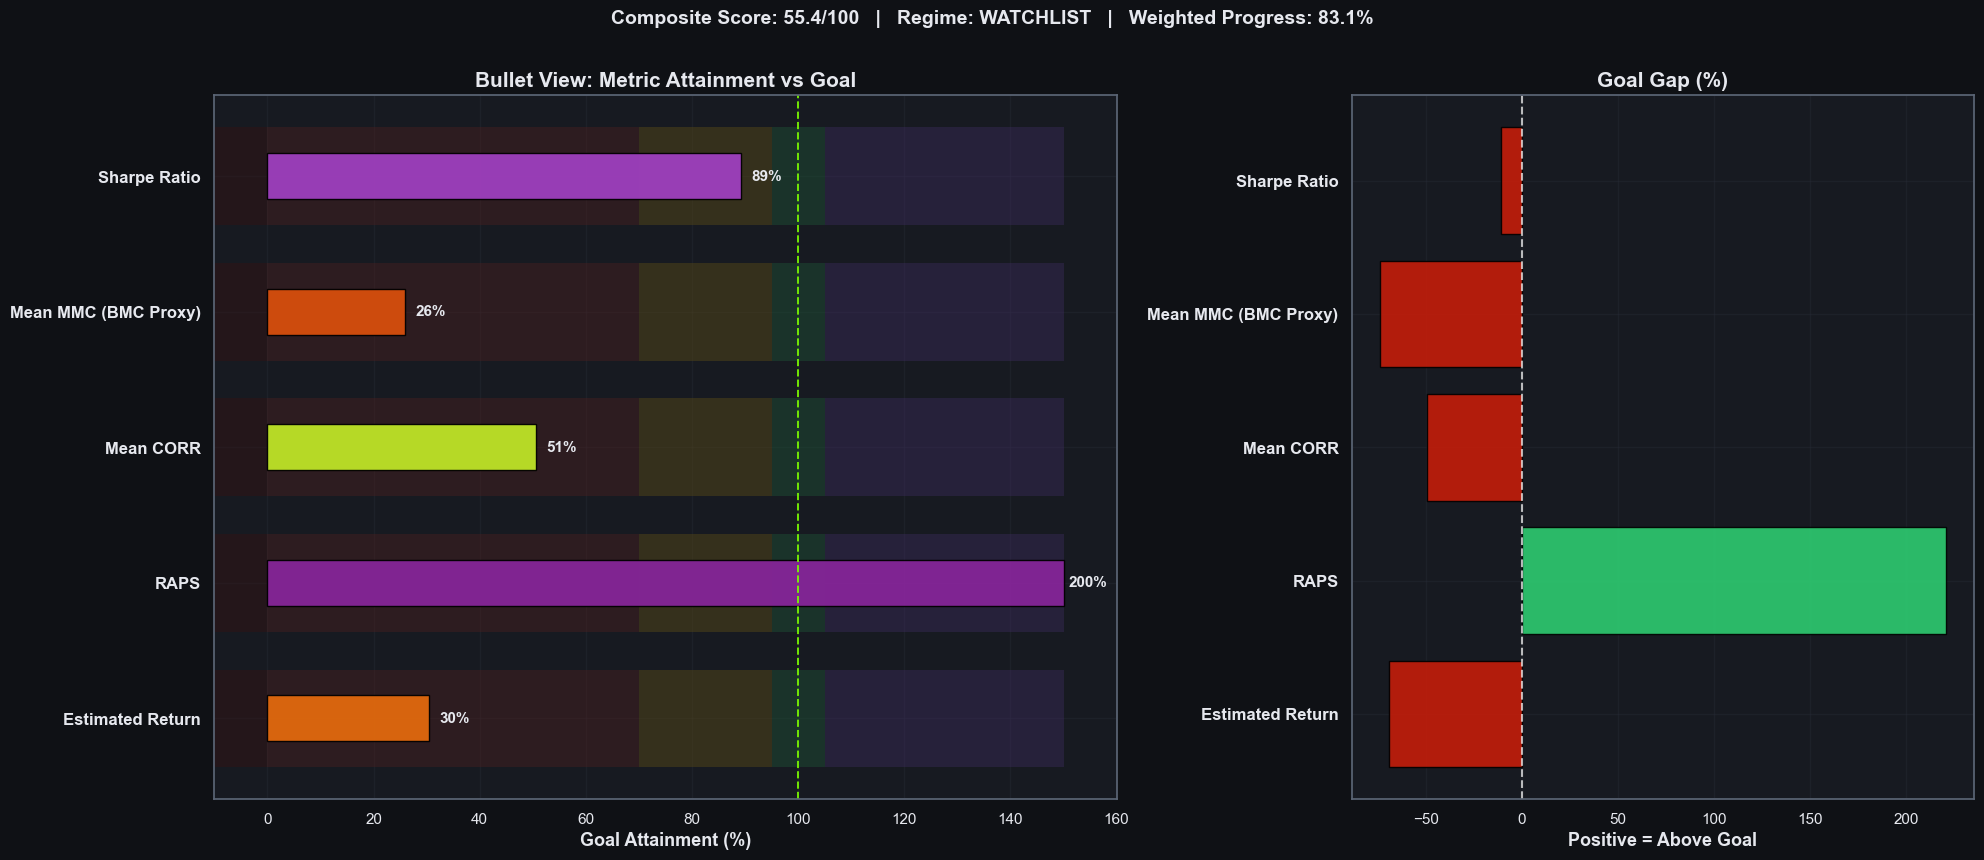

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,+7.62%,+25.00%,-69.5%,30.5%,🔴 BELOW,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,Mean MMC (BMC Proxy),+0.00259,+0.01000,-74.1%,25.9%,🔴 BELOW,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,Mean CORR,+0.01112,+0.02200,-49.4%,50.6%,🟠 LAGGING,Official Numerai correlation score; strong models are often 0.01-0.03
Payout,RAPS,+0.3208,+0.1000,+220.8%,200.0%,🟣 ABOVE TARGET !!!,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Quality,Win Rate,84.1%,85.0%,-1.1%,98.9%,🟡 CLOSE,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Payout Sharpe,+0.4294,+1.2500,-65.6%,34.4%,🔴 BELOW,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,Sharpe Ratio,+0.8921,+1.0000,-10.8%,89.2%,🟡 CLOSE,Risk-adjusted return consistency
Risk,Max Drawdown,-0.07963,-0.10000,+20.4%,120.4%,🟢 MET,Worst sustained CORR cumulative loss
Risk,MMC Volatility,+0.01085,—,—,—,—,Standard deviation of era-by-era MMC


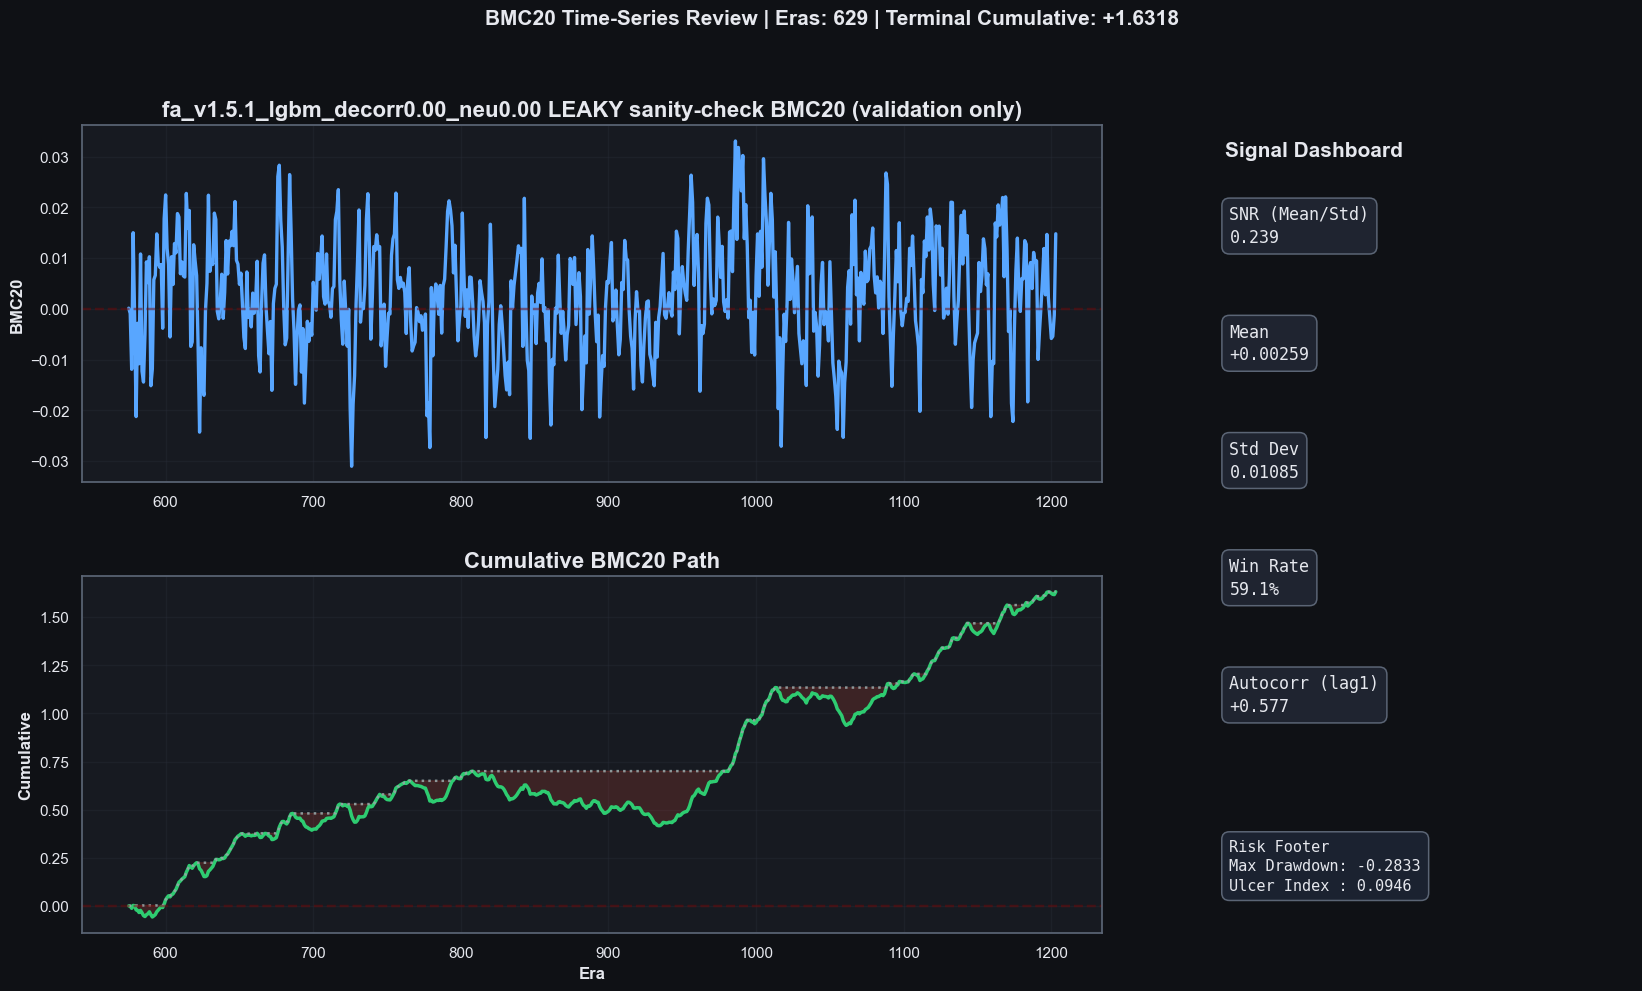

,era,target_ender_20,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20,target_caroline_20,target_delta_20,target_tyler_20,target_sam_20,target_echo_20,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,feature_donnard_groutier_twinkle,feature_elusive_vapoury_accomplice,feature_geminate_crummiest_scourer,feature_glandered_unimproved_peafowl,feature_hempen_unionist_cone,feature_illuminated_gambrel_noria,feature_jacobinical_symmetric_roll,feature_jewish_stained_disembowelment,feature_lacklustre_centroidal_schweitzer,feature_limiest_heliolithic_york,feature_maledictive_latter_psellism,feature_mendelian_undiscording_avion,feature_musicianly_aspirate_creativity,feature_petty_upraised_caddice,feature_pottier_unmanly_collyrium,feature_reclaimed_insurrectional_moneyer,feature_saddening_unsound_rustling,feature_simulated_nonclassified_intercessor,feature_snakiest_somalian_wavelet,feature_splanchnic_notional_pint,feature_strained_equivocal_phoneme,feature_stretchy_spiniest_fizgig,feature_toltec_korean_disfavourer,feature_transisthmian_yogic_linden,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute,prediction
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
n000101811a8a843,575,0.5,0.5,0.75,0.75,0.50,0.50,0.50,0.75,0.50,0.75,0.75,0.50,0.75,0.75,0.50,0.75,0.75,0.75,0,2,1,2,2,1,1,2,2,0,0,2,3,0,3,4,3,1,2,0,0,1,0,2,2,3,2,1,4,1,1,1,1,2,3,0,2,2,1,3,2,0,0.084764
n001e1318d5072ac,575,0.5,0.5,0.00,0.25,0.25,0.25,0.25,0.25,0.25,0.00,0.00,0.00,0.00,0.00,0.25,0.25,0.00,0.25,1,1,3,2,1,3,3,4,4,3,2,1,0,3,0,3,3,4,1,2,1,3,3,3,1,3,3,2,2,3,4,3,2,4,3,2,2,3,1,1,0,1,0.801502
n002a9c5ab785cbb,575,0.5,0.5,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,1,4,3,2,4,2,1,0,3,0,1,4,4,3,1,1,2,1,4,3,1,4,2,0,3,3,3,3,4,4,2,0,1,0,1,4,0,4,1,1,1,0,0.132690
n002ccf6d0e8c5ad,575,0.0,0.0,0.00,0.25,0.25,0.25,0.00,0.00,0.00,0.00,0.25,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0,1,0,3,3,0,0,3,0,3,3,0,3,0,4,1,1,1,1,0,4,4,1,1,4,4,3,2,1,4,3,2,4,0,0,0,0,0,4,3,4,0,0.572246
n0041544c345c91d,575,0.5,0.5,0.75,0.75,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.75,0.50,0.50,0.50,0.75,0.50,0.50,0,3,4,2,2,3,1,2,2,1,3,1,0,3,3,0,3,2,2,3,4,3,2,1,2,4,1,4,0,2,4,4,4,3,2,2,3,2,2,0,2,1,0.952969


In [20]:
print("\nLeaky validation sanity-check metrics (full-data retrain):")
display_metrics_table(full_validation_leaky_metrics, extended=True)

plot_metric_over_time(
    per_era_df=full_validation_leaky_per_era,
    metric="BMC20",
    title=f"{MODEL_NAME} LEAKY sanity-check BMC20 (validation only)",
)

display(full_validation_leaky_frame.head())